# 01 - Data Exploration & Visualization

This notebook provides interactive exploration of:
1. **Synthetic twin cohorts** — understand the data structure
2. **Connectivity matrices** — heatmaps showing brain network patterns
3. **Graph structure** — node features, edge distributions
4. **Twin pair comparisons** — MZ vs DZ connectivity differences

Use this for:
- Generating dissertation/grant figures
- Debugging when real data arrives
- Understanding what the model sees

In [1]:
# Setup: Add project root to path
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Project root: {REPO_ROOT}")

Project root: /Users/uchemudiuzoka/NeuroSpectral-GNN


In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from src.preprocessing.synthetic import SyntheticCohortConfig, generate_cohort, save_synthetic_cohort
from src.preprocessing.graph import GraphBuildConfig
from src.utils import TwinBrainDataset, get_device, set_seed

set_seed(42)
device = get_device()
print(f"Device: {device}")

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

/Users/uchemudiuzoka/miniforge3/envs/neurognn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


---
## 1. Generate a Synthetic Cohort

We'll create a small cohort to explore. The synthetic generator mimics the ACE twin model:
- **A** (Additive genetic): Shared 100% for MZ, ~50% for DZ
- **C** (Common environment): Shared for both (not modeled here)
- **E** (Unique environment): Independent per twin

In [3]:
# Generate synthetic cohort
cfg = SyntheticCohortConfig(
    n_mz_pairs=20,
    n_dz_pairs=20,
    n_rois=100,  # Schaefer-100 equivalent
    heritability=0.6,  # 60% of variance is genetic
    prs_dim=16,  # Include PRS for multimodal demo
    seed=42,
    graph_config=GraphBuildConfig(
        sparsify_strategy="proportional",
        keep_top_fraction=0.2,
        node_feature_mode="profile",
    ),
)

# Generate raw connectivities + pairs metadata
connectivities, pairs, prs_vectors = generate_cohort(cfg)

print(f"Generated {len(connectivities)} subjects")
print(f"Generated {len(pairs)} pairs")
print(f"MZ pairs: {sum(1 for p in pairs if p.zygosity == 'MZ')}")
print(f"DZ pairs: {sum(1 for p in pairs if p.zygosity == 'DZ')}")
print(f"Connectivity matrix shape: {list(connectivities.values())[0].shape}")
if prs_vectors:
    print(f"PRS vector shape: {list(prs_vectors.values())[0].shape}")

Generated 80 subjects
Generated 40 pairs
MZ pairs: 20
DZ pairs: 20
Connectivity matrix shape: (100, 100)
PRS vector shape: (16,)


---
## 2. Connectivity Matrix Heatmaps

Each subject has a 100×100 Fisher-z transformed correlation matrix representing functional connectivity between brain regions.

In [4]:
def plot_connectivity_matrix(conn: np.ndarray, title: str = "Connectivity Matrix", ax=None):
    """Plot a single connectivity matrix as a heatmap."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 7))
    
    # Use diverging colormap centered at 0
    vmax = np.abs(conn).max()
    im = ax.imshow(conn, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='equal')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('ROI')
    ax.set_ylabel('ROI')
    plt.colorbar(im, ax=ax, label='Fisher-z correlation', shrink=0.8)
    return ax

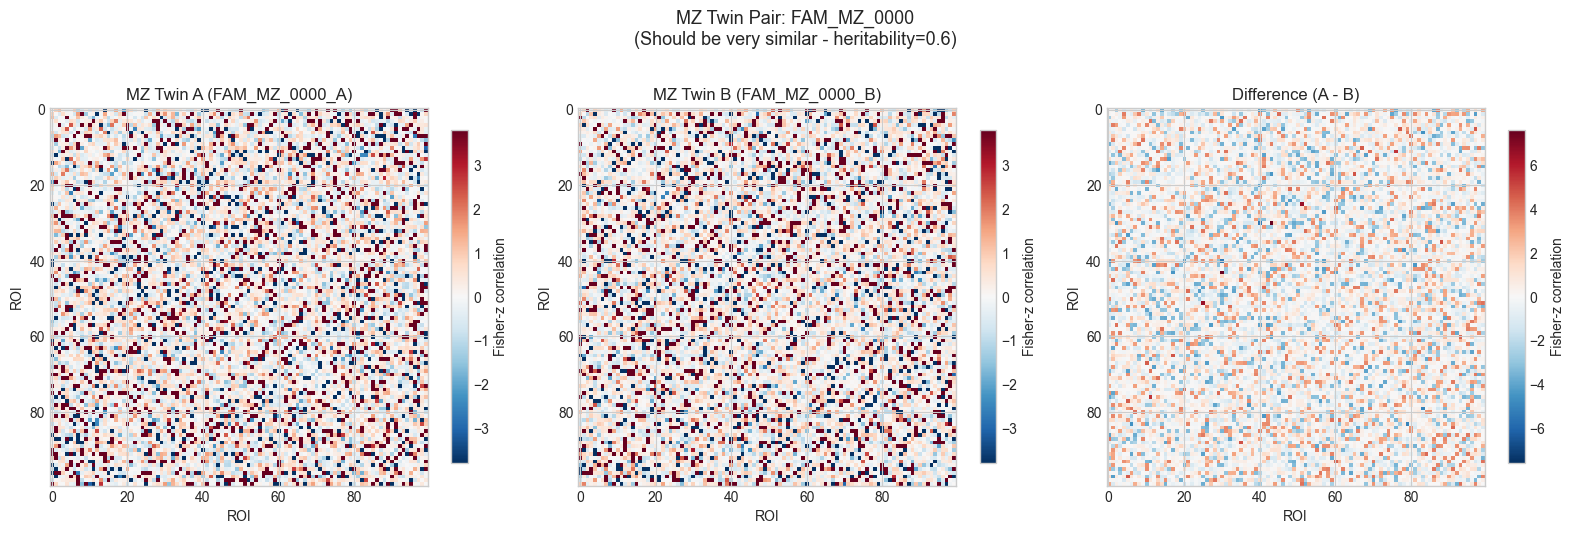

Correlation between MZ twins: 0.533


In [5]:
# Plot connectivity for first MZ pair
mz_pair = [p for p in pairs if p.zygosity == 'MZ'][0]
conn_a = connectivities[mz_pair.subject_a]
conn_b = connectivities[mz_pair.subject_b]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_connectivity_matrix(conn_a, f"MZ Twin A ({mz_pair.subject_a})", axes[0])
plot_connectivity_matrix(conn_b, f"MZ Twin B ({mz_pair.subject_b})", axes[1])
plot_connectivity_matrix(conn_a - conn_b, "Difference (A - B)", axes[2])

fig.suptitle(f"MZ Twin Pair: {mz_pair.family_id}\n(Should be very similar - heritability={cfg.heritability})", 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Correlation between MZ twins: {np.corrcoef(conn_a.flatten(), conn_b.flatten())[0,1]:.3f}")

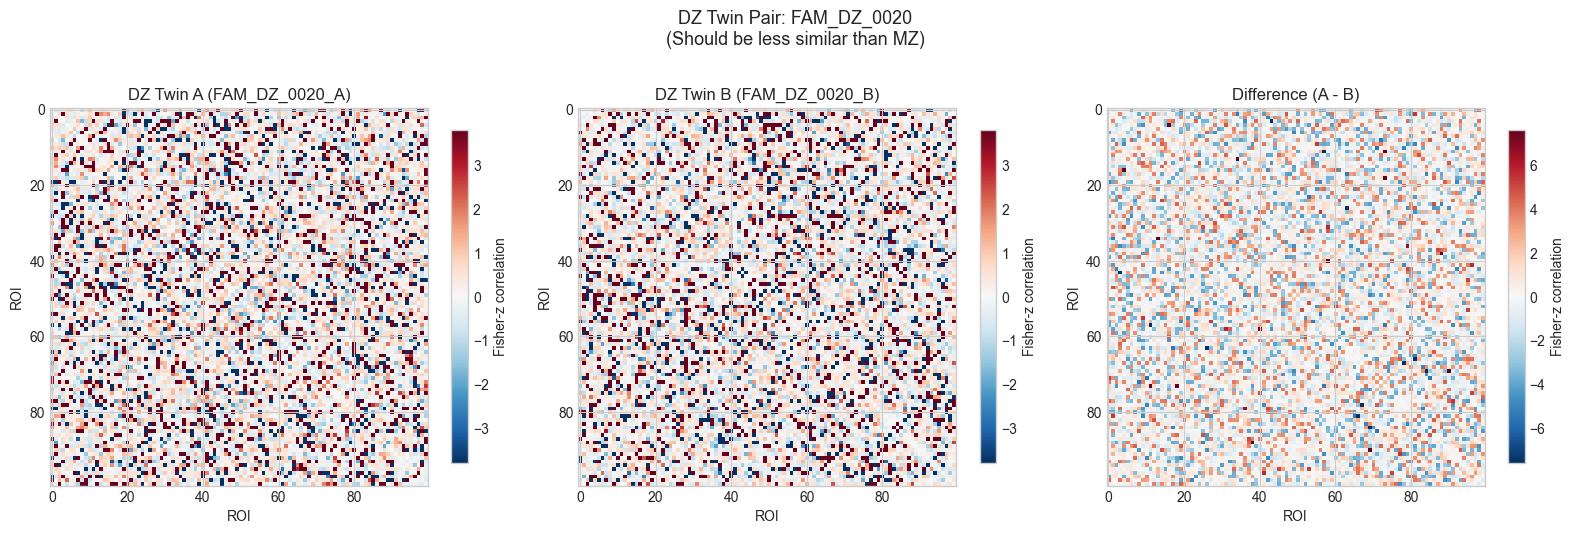

Correlation between DZ twins: 0.306


In [6]:
# Compare with DZ pair
dz_pair = [p for p in pairs if p.zygosity == 'DZ'][0]
conn_a_dz = connectivities[dz_pair.subject_a]
conn_b_dz = connectivities[dz_pair.subject_b]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_connectivity_matrix(conn_a_dz, f"DZ Twin A ({dz_pair.subject_a})", axes[0])
plot_connectivity_matrix(conn_b_dz, f"DZ Twin B ({dz_pair.subject_b})", axes[1])
plot_connectivity_matrix(conn_a_dz - conn_b_dz, "Difference (A - B)", axes[2])

fig.suptitle(f"DZ Twin Pair: {dz_pair.family_id}\n(Should be less similar than MZ)", 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Correlation between DZ twins: {np.corrcoef(conn_a_dz.flatten(), conn_b_dz.flatten())[0,1]:.3f}")

---
## 3. Twin Similarity Distribution

The key insight: **MZ correlations should be higher than DZ correlations**. The gap is the genetic signal.

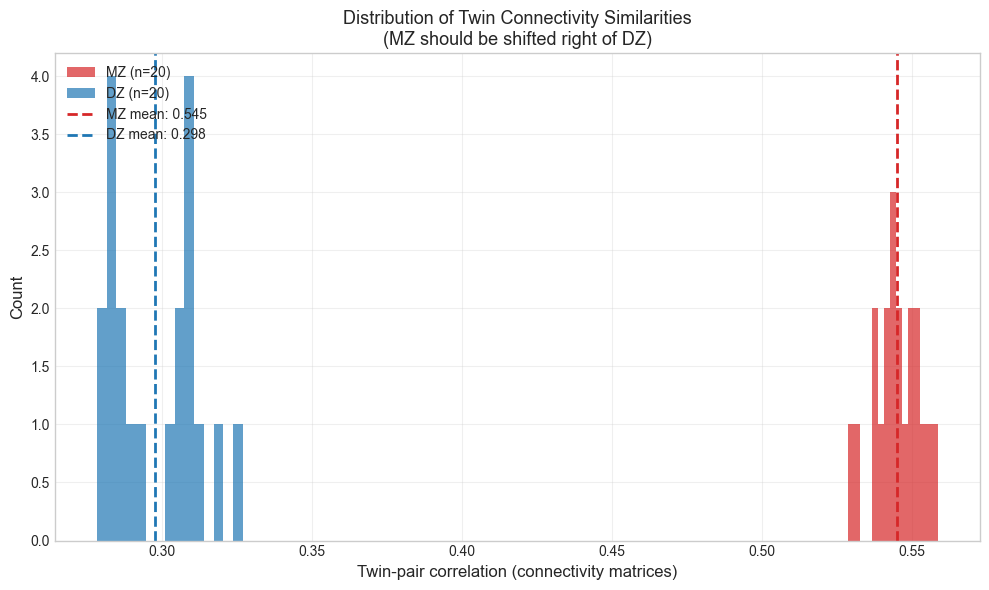


Raw-matrix Falconer heritability estimate:
  h² = 2 * (r_MZ - r_DZ)
  h² = 2 * (0.545 - 0.298)
  h² = 0.495

Ground truth h² = 0.6


In [7]:
# Compute pairwise correlations for all twins
mz_correlations = []
dz_correlations = []

for pair in pairs:
    a = connectivities[pair.subject_a].flatten()
    b = connectivities[pair.subject_b].flatten()
    r = np.corrcoef(a, b)[0, 1]
    
    if pair.zygosity == 'MZ':
        mz_correlations.append(r)
    else:
        dz_correlations.append(r)

# Plot distributions
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(mz_correlations, bins=15, alpha=0.7, label=f'MZ (n={len(mz_correlations)})', color='#d62728')
ax.hist(dz_correlations, bins=15, alpha=0.7, label=f'DZ (n={len(dz_correlations)})', color='#1f77b4')

ax.axvline(np.mean(mz_correlations), color='#d62728', linestyle='--', lw=2, 
           label=f'MZ mean: {np.mean(mz_correlations):.3f}')
ax.axvline(np.mean(dz_correlations), color='#1f77b4', linestyle='--', lw=2,
           label=f'DZ mean: {np.mean(dz_correlations):.3f}')

ax.set_xlabel('Twin-pair correlation (connectivity matrices)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Twin Connectivity Similarities\n(MZ should be shifted right of DZ)', fontsize=13)
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Compute Falconer's heritability estimate
r_mz = np.mean(mz_correlations)
r_dz = np.mean(dz_correlations)
h2_falconer = 2 * (r_mz - r_dz)

print(f"\n{'='*50}")
print(f"Raw-matrix Falconer heritability estimate:")
print(f"  h² = 2 * (r_MZ - r_DZ)")
print(f"  h² = 2 * ({r_mz:.3f} - {r_dz:.3f})")
print(f"  h² = {h2_falconer:.3f}")
print(f"\nGround truth h² = {cfg.heritability}")
print(f"{'='*50}")

---
## 4. Graph Structure Exploration

After sparsification, we keep only the top 20% of edges. Let's look at the resulting graph.

In [8]:
# Save cohort to disk and load as PyG Data objects
import tempfile

with tempfile.TemporaryDirectory() as tmpdir:
    tmpdir = Path(tmpdir)
    save_synthetic_cohort(cfg, tmpdir)
    
    # Load one subject (weights_only=False: PyG Data objects are full pickles, not
    # pure tensor checkpoints — required from PyTorch 2.6+ default)
    subject_id = list(connectivities.keys())[0]
    data = torch.load(
        tmpdir / "subjects" / f"{subject_id}.pt",
        map_location="cpu",
        weights_only=False,
    )

print(f"PyG Data object for {subject_id}:")
print(f"  - Node features (x): {data.x.shape}")
print(f"  - Edge index: {data.edge_index.shape}")
print(f"  - Edge weights: {data.edge_attr.shape if hasattr(data, 'edge_attr') else 'None'}")
print(f"  - Number of nodes: {data.num_nodes}")
print(f"  - Number of edges: {data.num_edges}")
print(f"  - Graph density: {data.num_edges / (data.num_nodes * (data.num_nodes - 1)):.2%}")

PyG Data object for FAM_MZ_0000_A:
  - Node features (x): torch.Size([100, 100])
  - Edge index: torch.Size([2, 1980])
  - Edge weights: torch.Size([1980])
  - Number of nodes: 100
  - Number of edges: 1980
  - Graph density: 20.00%


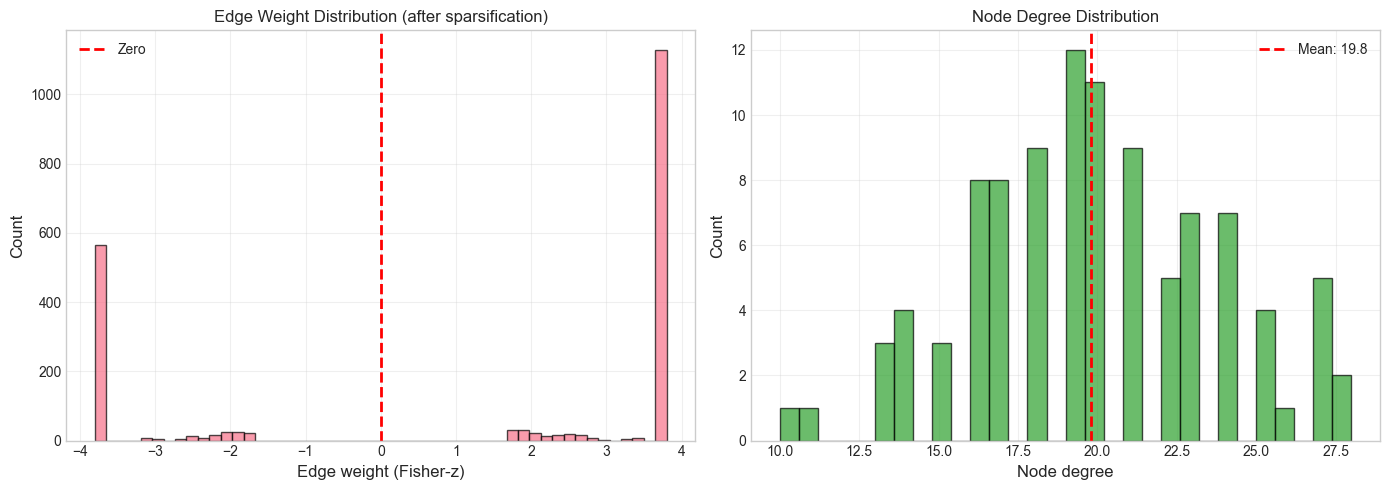

Edge weight stats: min=-3.800, max=3.800, mean=1.131
Negative edges: 688 (34.7%)


In [9]:
# Edge weight distribution
if hasattr(data, 'edge_attr') and data.edge_attr is not None:
    weights = data.edge_attr.numpy()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(weights, bins=50, edgecolor='black', alpha=0.7)
    axes[0].axvline(0, color='red', linestyle='--', lw=2, label='Zero')
    axes[0].set_xlabel('Edge weight (Fisher-z)', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].set_title('Edge Weight Distribution (after sparsification)', fontsize=12)
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Node degree distribution
    edge_index = data.edge_index.numpy()
    degrees = np.bincount(edge_index[0], minlength=data.num_nodes)
    
    axes[1].hist(degrees, bins=30, edgecolor='black', alpha=0.7, color='#2ca02c')
    axes[1].axvline(np.mean(degrees), color='red', linestyle='--', lw=2, 
                    label=f'Mean: {np.mean(degrees):.1f}')
    axes[1].set_xlabel('Node degree', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].set_title('Node Degree Distribution', fontsize=12)
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Edge weight stats: min={weights.min():.3f}, max={weights.max():.3f}, mean={weights.mean():.3f}")
    print(f"Negative edges: {(weights < 0).sum()} ({(weights < 0).mean():.1%})")
else:
    print("No edge weights stored")

---
## 5. Node Features Visualization

With `node_feature_mode='profile'`, each node's feature vector is its row in the connectivity matrix (its "connectivity profile").

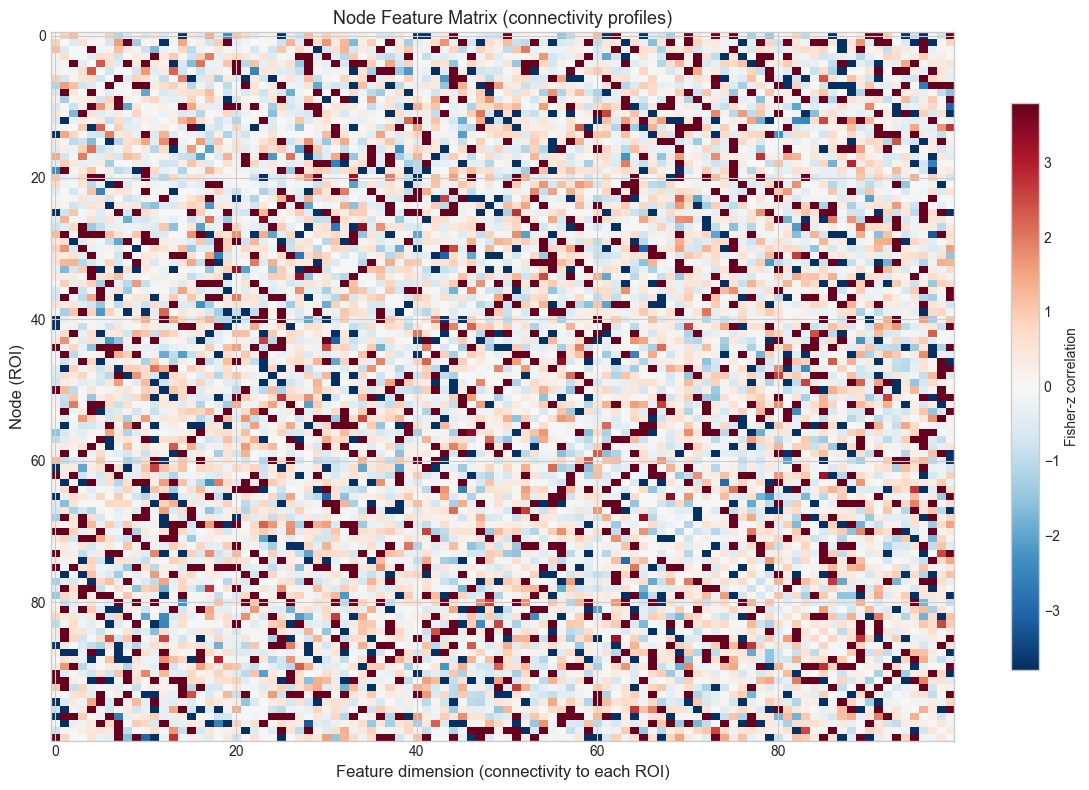

In [10]:
# Visualize node features as a heatmap
fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(data.x.numpy(), aspect='auto', cmap='RdBu_r')
ax.set_xlabel('Feature dimension (connectivity to each ROI)', fontsize=12)
ax.set_ylabel('Node (ROI)', fontsize=12)
ax.set_title('Node Feature Matrix (connectivity profiles)', fontsize=13)
plt.colorbar(im, ax=ax, label='Fisher-z correlation', shrink=0.8)

plt.tight_layout()
plt.show()

---
## 6. PRS (Polygenic Risk Score) Visualization

For multimodal fusion, each subject has an emulated PRS vector.

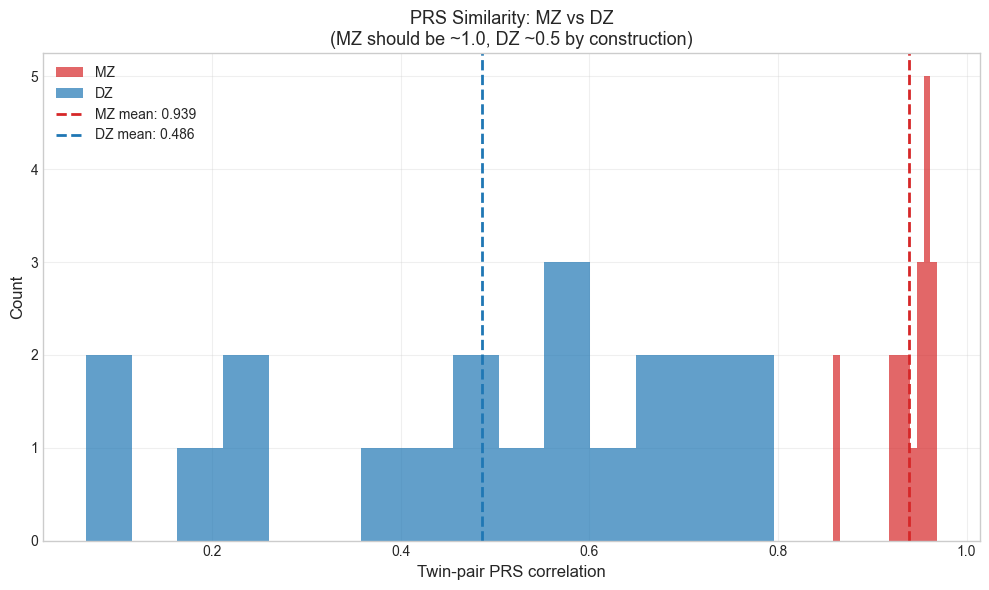

In [11]:
if prs_vectors:
    # Compare PRS vectors for MZ vs DZ
    mz_prs_corrs = []
    dz_prs_corrs = []
    
    for pair in pairs:
        prs_a = prs_vectors[pair.subject_a]
        prs_b = prs_vectors[pair.subject_b]
        r = np.corrcoef(prs_a, prs_b)[0, 1]
        
        if pair.zygosity == 'MZ':
            mz_prs_corrs.append(r)
        else:
            dz_prs_corrs.append(r)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.hist(mz_prs_corrs, bins=15, alpha=0.7, label=f'MZ', color='#d62728')
    ax.hist(dz_prs_corrs, bins=15, alpha=0.7, label=f'DZ', color='#1f77b4')
    
    ax.axvline(np.mean(mz_prs_corrs), color='#d62728', linestyle='--', lw=2,
               label=f'MZ mean: {np.mean(mz_prs_corrs):.3f}')
    ax.axvline(np.mean(dz_prs_corrs), color='#1f77b4', linestyle='--', lw=2,
               label=f'DZ mean: {np.mean(dz_prs_corrs):.3f}')
    
    ax.set_xlabel('Twin-pair PRS correlation', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('PRS Similarity: MZ vs DZ\n(MZ should be ~1.0, DZ ~0.5 by construction)', fontsize=13)
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No PRS vectors generated (set prs_dim > 0 in config)")

---
## 7. Mean Connectivity Template

The synthetic generator uses a block-diagonal mean template to simulate brain modularity.

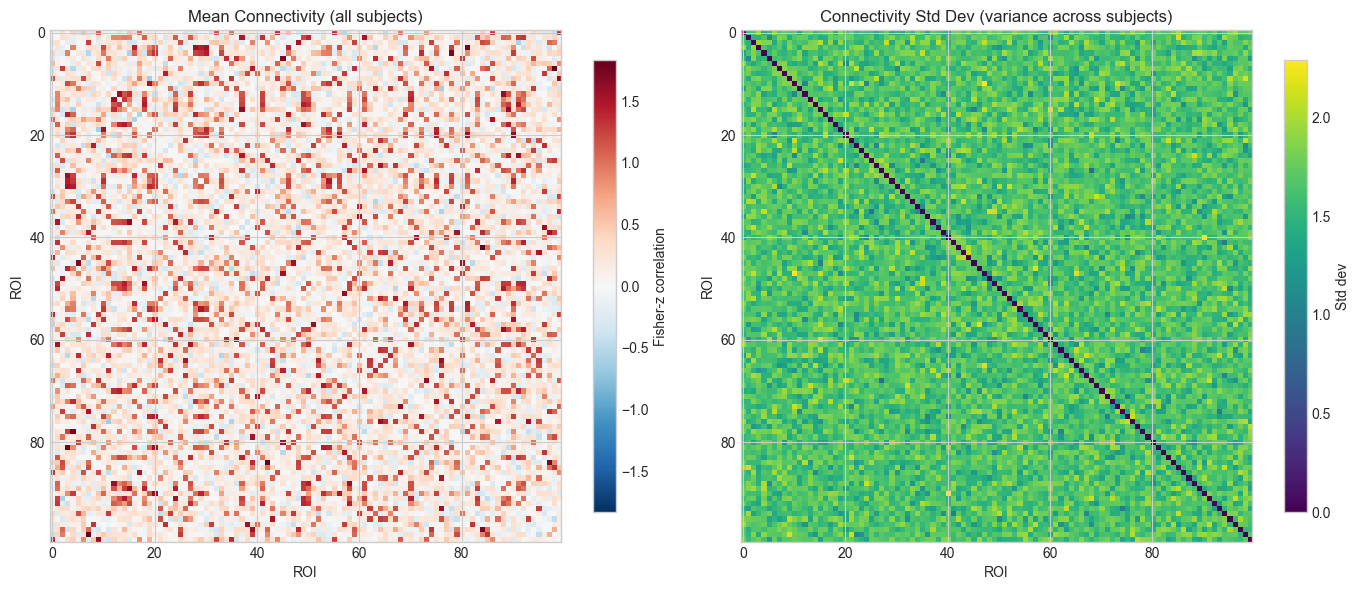

In [12]:
# Compute mean connectivity across all subjects
all_conns = np.stack(list(connectivities.values()))
mean_conn = all_conns.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_connectivity_matrix(mean_conn, "Mean Connectivity (all subjects)", axes[0])

# Standard deviation (shows where variance is highest)
std_conn = all_conns.std(axis=0)
im = axes[1].imshow(std_conn, cmap='viridis', aspect='equal')
axes[1].set_title('Connectivity Std Dev (variance across subjects)', fontsize=12)
axes[1].set_xlabel('ROI')
axes[1].set_ylabel('ROI')
plt.colorbar(im, ax=axes[1], label='Std dev', shrink=0.8)

plt.tight_layout()
plt.show()

---
## 8. Save Figures for Dissertation

Run this cell to save publication-quality figures.

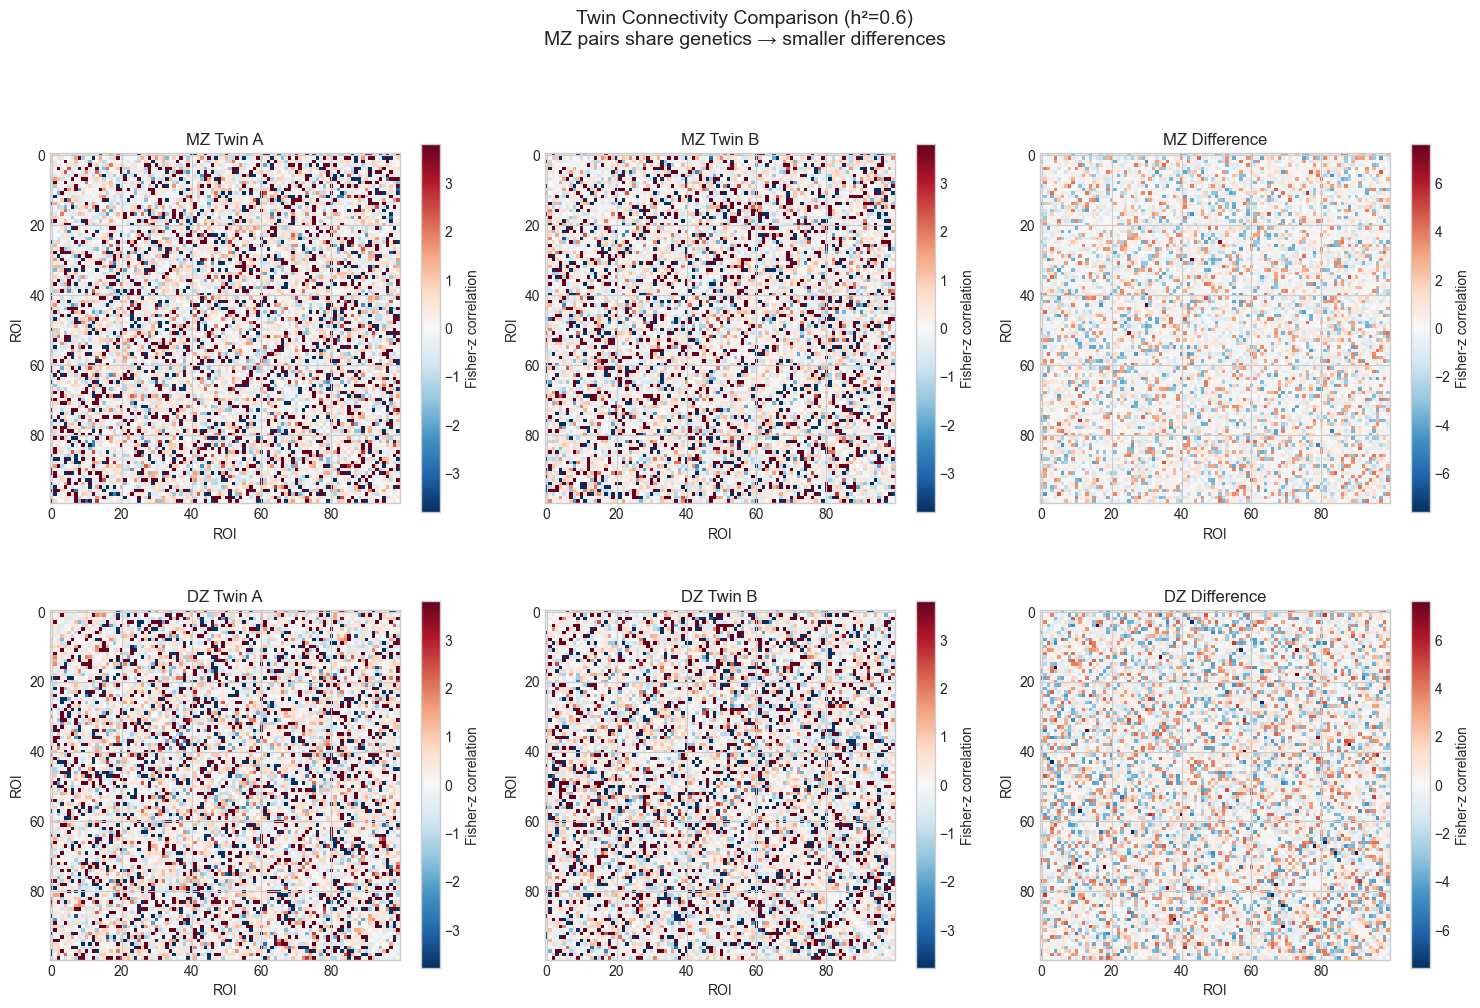

Saved: /Users/uchemudiuzoka/NeuroSpectral-GNN/figures/twin_connectivity_comparison.png


In [13]:
# Create figures directory
figures_dir = REPO_ROOT / "figures"
figures_dir.mkdir(exist_ok=True)

# 1. Twin comparison figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# MZ pair
plot_connectivity_matrix(conn_a, f"MZ Twin A", axes[0, 0])
plot_connectivity_matrix(conn_b, f"MZ Twin B", axes[0, 1])
plot_connectivity_matrix(conn_a - conn_b, "MZ Difference", axes[0, 2])

# DZ pair
plot_connectivity_matrix(conn_a_dz, f"DZ Twin A", axes[1, 0])
plot_connectivity_matrix(conn_b_dz, f"DZ Twin B", axes[1, 1])
plot_connectivity_matrix(conn_a_dz - conn_b_dz, "DZ Difference", axes[1, 2])

fig.suptitle(f"Twin Connectivity Comparison (h²={cfg.heritability})\nMZ pairs share genetics → smaller differences", 
             fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(figures_dir / "twin_connectivity_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: {figures_dir / 'twin_connectivity_comparison.png'}")

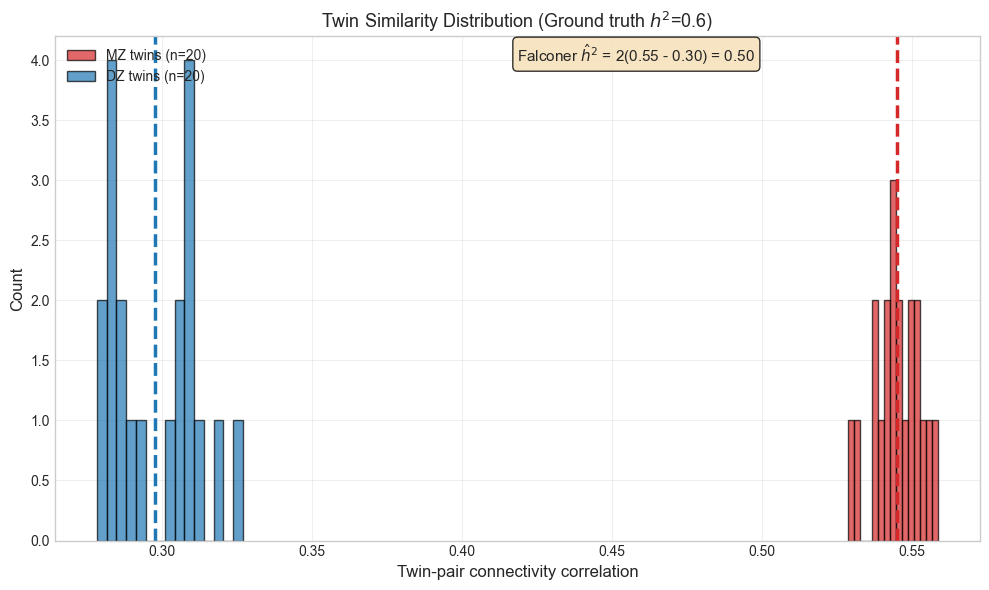

Saved: /Users/uchemudiuzoka/NeuroSpectral-GNN/figures/twin_similarity_distribution.png


In [14]:
# 2. Similarity distribution figure
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(mz_correlations, bins=15, alpha=0.7, label=f'MZ twins (n={len(mz_correlations)})', 
        color='#d62728', edgecolor='black')
ax.hist(dz_correlations, bins=15, alpha=0.7, label=f'DZ twins (n={len(dz_correlations)})', 
        color='#1f77b4', edgecolor='black')

ax.axvline(r_mz, color='#d62728', linestyle='--', lw=2.5)
ax.axvline(r_dz, color='#1f77b4', linestyle='--', lw=2.5)

# Add Falconer annotation
ax.annotate(f'Falconer $\\hat{{h}}^2$ = 2({r_mz:.2f} - {r_dz:.2f}) = {h2_falconer:.2f}',
            xy=(0.5, 0.95), xycoords='axes fraction', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_xlabel('Twin-pair connectivity correlation', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'Twin Similarity Distribution (Ground truth $h^2$={cfg.heritability})', fontsize=13)
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(figures_dir / "twin_similarity_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: {figures_dir / 'twin_similarity_distribution.png'}")

---
## Summary

**Key takeaways from this exploration:**

1. **Connectivity matrices** show clear structure (block-diagonal from brain modules)
2. **MZ twins have higher correlation** than DZ twins (the genetic signal we're learning)
3. **Falconer's formula** gives a rough h² estimate from raw correlations
4. **Graph sparsification** keeps top 20% edges, creating a sparse but informative graph
5. **Node features** (connectivity profiles) capture each region's network role

**These figures are useful for:**
- Dissertation methods chapter
- Grant proposal supplementary materials
- Debugging when real data arrives (compare real vs synthetic patterns)